# Data reading


In [1]:
%matplotlib inline

from pathlib import Path
import pickle
import re

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


In [2]:
DATA_DIR = Path.cwd()

mat_files = sorted(DATA_DIR.glob("*.mat"))
print(f"Data folder: {DATA_DIR.resolve()}")
print(f"MAT files found: {len(mat_files)}")
for file in mat_files:
    print(file.name)


Data folder: C:\Users\anacs\Documentos\ic-labdin\BEPE\Data\Ana_PySINDy_SNLR
MAT files found: 20
FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-down.mat
FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-up.mat
FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-down.mat
FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-up.mat
FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-down.mat
FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-up.mat
FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-down.mat
FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-up.mat
FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-down.mat
FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-up.mat
time_base_000mA_1000mg_50-150_Hz_sweep-up-down.mat
time_base_000mA_1500mg_50-150_Hz_sweep-up-down.mat
time_base_000mA_2000mg_50-150_Hz_sweep-up-down.mat
time_base_000mA_2500mg_50-150_Hz_sweep-up-down.mat
time_base_000mA_500mg_50-150_Hz_sweep-up-down.mat
time_ponta_000mA_1000mg_50-150_Hz_sweep-up-down.mat
time_ponta_000mA_1500mg_50-150_Hz_sweep-up-down.mat
time_ponta_000mA_2000mg_50-1

In [3]:
def read_mat(path):
    data = loadmat(path, squeeze_me=True, struct_as_record=False)
    return {key: value for key, value in data.items() if not key.startswith("__")}


def get_nested(obj, path):
    for part in path.split("."):
        obj = getattr(obj, part)
    return obj


def split_half(values):
    values = np.asarray(values).squeeze()
    middle = values.shape[0] // 2
    return values[:middle], values[middle:]


In [4]:
raw_data = {}
FRF = {}
time_base = {}
time_tip = {}
time_axis = {}

for path in mat_files:
    key = path.stem
    data = read_mat(path)
    raw_data[key] = data

    if key.startswith("FRF_ponta-base"):
        # Testlab FRF files usually store the useful arrays inside FRF.
        frf = data["FRF"]
        FRF[key] = frf

    elif key.startswith("time_base"):
        signal = data["Signal"]
        time_base[key] = signal.y_values.values
        start = float(signal.x_values.start_value)
        dt = float(signal.x_values.increment)
        n = int(signal.x_values.number_of_values)
        time_axis[key] = start + np.arange(n) * dt

    elif key.startswith("time_ponta"):
        signal = data["Signal"]
        time_tip[key] = signal.y_values.values
        start = float(signal.x_values.start_value)
        dt = float(signal.x_values.increment)
        n = int(signal.x_values.number_of_values)
        time_axis[key] = start + np.arange(n) * dt

print(f"FRF files: {len(FRF)}")
print(f"Base time files: {len(time_base)}")
print(f"Tip time files: {len(time_tip)}")


FRF files: 10
Base time files: 5
Tip time files: 5


In [5]:
time_base_split = {}
time_tip_split = {}
time_axis_split = {}

for key, values in time_base.items():
    up, down = split_half(values)
    t_up, t_down = split_half(time_axis[key])
    time_base_split[f"{key}__sweep_up"] = up
    time_base_split[f"{key}__sweep_down"] = down
    time_axis_split[f"{key}__sweep_up"] = t_up
    time_axis_split[f"{key}__sweep_down"] = t_down

for key, values in time_tip.items():
    up, down = split_half(values)
    t_up, t_down = split_half(time_axis[key])
    time_tip_split[f"{key}__sweep_up"] = up
    time_tip_split[f"{key}__sweep_down"] = down
    time_axis_split[f"{key}__sweep_up"] = t_up
    time_axis_split[f"{key}__sweep_down"] = t_down

print(f"Split base signals: {len(time_base_split)}")
print(f"Split tip signals: {len(time_tip_split)}")


Split base signals: 10
Split tip signals: 10


## Frequency-domain plots


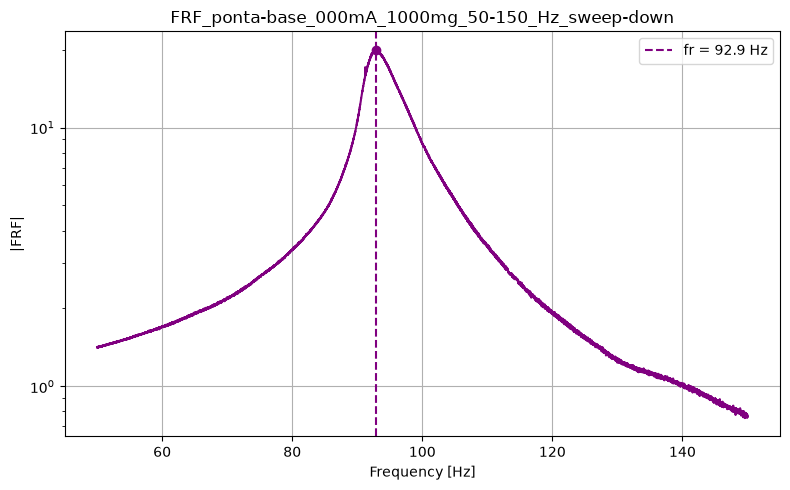

FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-down: resonance frequency = 92.89 Hz


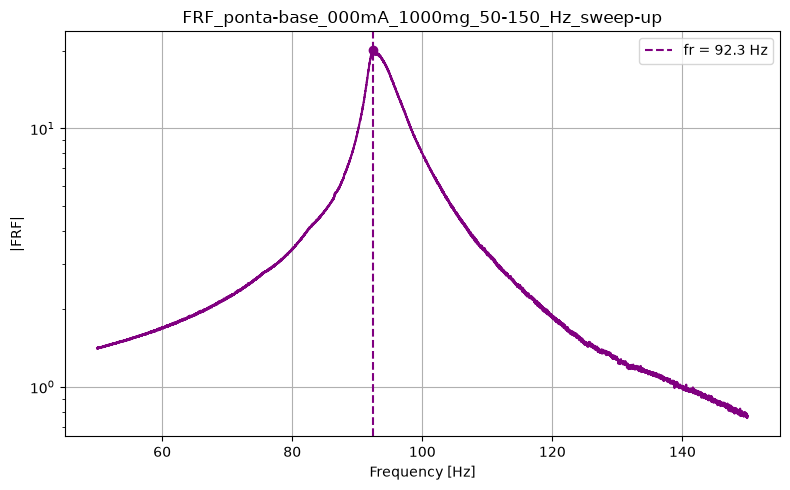

FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-up: resonance frequency = 92.35 Hz


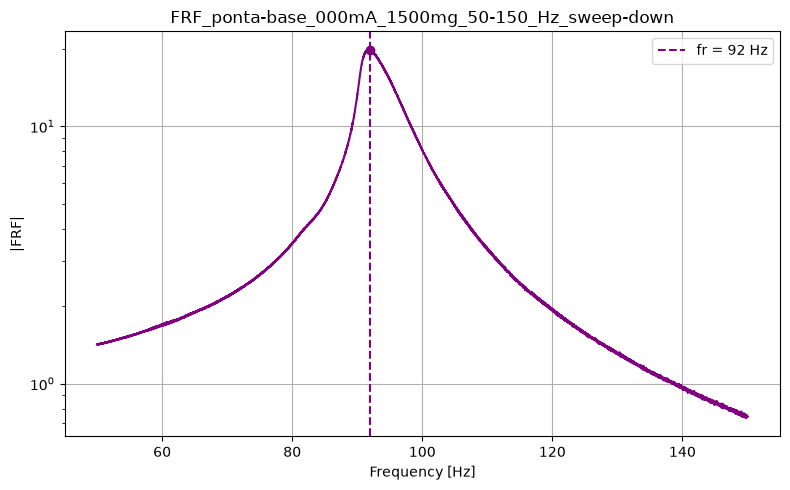

FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-down: resonance frequency = 91.97 Hz


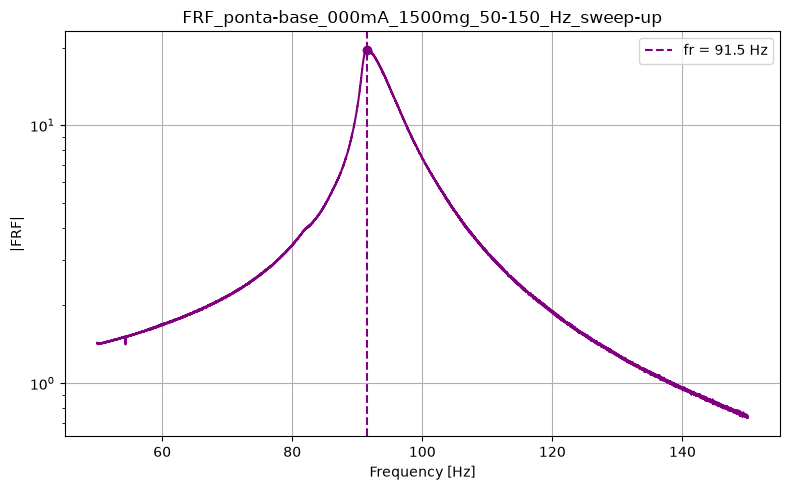

FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-up: resonance frequency = 91.51 Hz


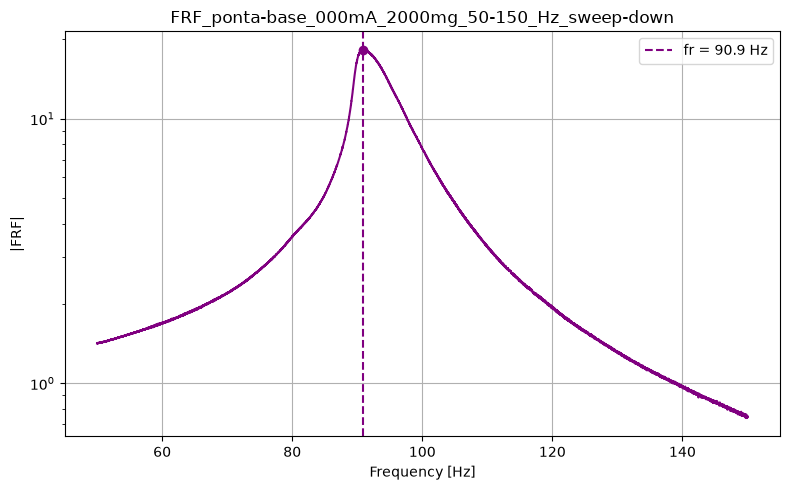

FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-down: resonance frequency = 90.91 Hz


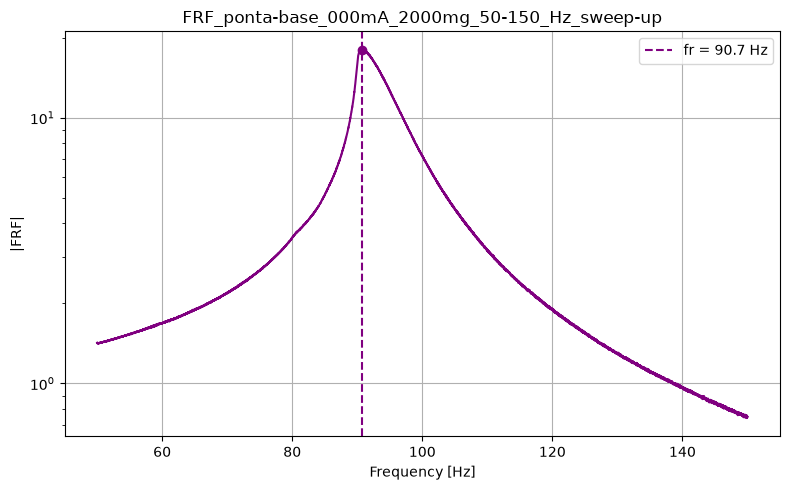

FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-up: resonance frequency = 90.72 Hz


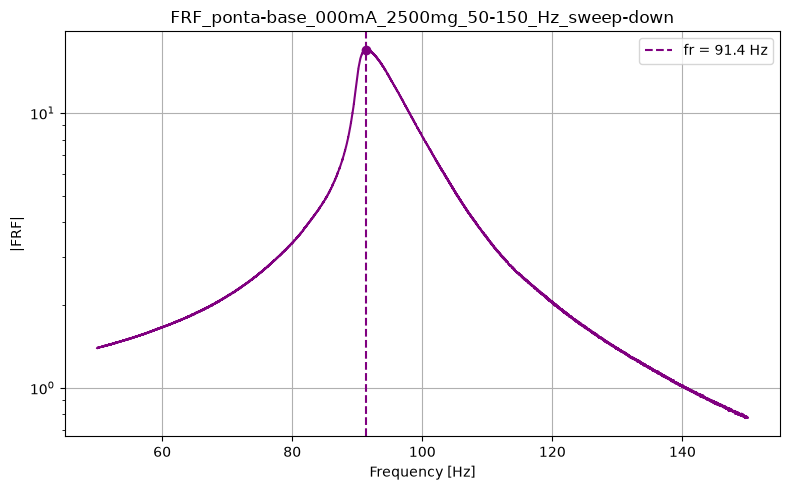

FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-down: resonance frequency = 91.37 Hz


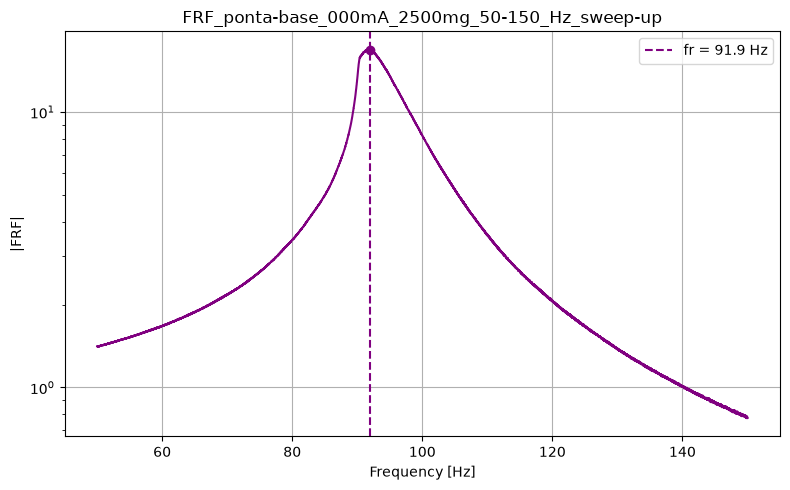

FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-up: resonance frequency = 91.91 Hz


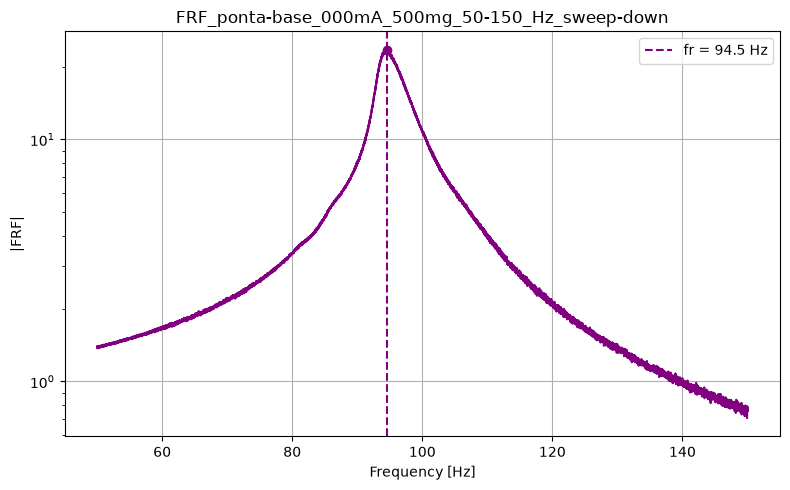

FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-down: resonance frequency = 94.53 Hz


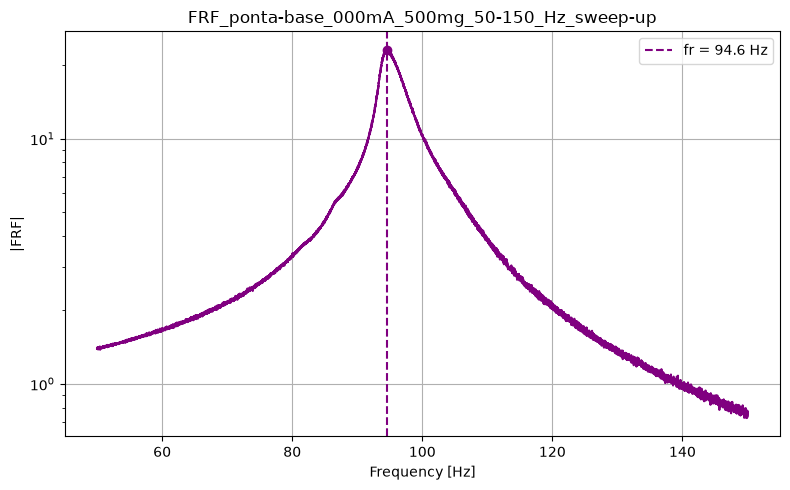

FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-up: resonance frequency = 94.64 Hz


In [6]:
for key, frf in FRF.items():
    match = re.search(r"(\d+(?:\.\d+)?)-(\d+(?:\.\d+)?)_Hz", key)
    if match is None:
        raise ValueError(f"Could not find frequency range in file name: {key}")

    fmin = float(match.group(1))
    fmax = float(match.group(2))

    # Testlab FRF files can store frequency/response in different nested fields.
    if hasattr(frf, "x_values") and hasattr(frf.x_values, "values"):
        frequency = np.asarray(frf.x_values.values).squeeze()
    elif hasattr(frf, "x_values") and hasattr(frf.x_values, "start_value"):
        freq_start = float(frf.x_values.start_value)
        freq_step = float(frf.x_values.increment)
        freq_n = int(frf.x_values.number_of_values)
        frequency = freq_start + np.arange(freq_n) * freq_step
    else:
        frequency = None

    if hasattr(frf, "y_values") and hasattr(frf.y_values, "values"):
        response = np.asarray(frf.y_values.values).squeeze()
    elif hasattr(frf, "Data"):
        response = np.asarray(frf.Data).squeeze()
    else:
        raise AttributeError(f"Could not find FRF response data in: {key}")

    if response.ndim > 1:
        # IUse the last column as the response.
        response = response[:, -1]

    if frequency is None or len(np.asarray(frequency).squeeze()) != len(response):
        frequency = np.linspace(fmin, fmax, len(response))

    magnitude = np.abs(response)
    peak_index = int(np.argmax(magnitude))
    resonance_frequency = frequency[peak_index]

    plt.figure(figsize=(8, 5))
    plt.semilogy(frequency, magnitude, color="purple")
    plt.axvline(resonance_frequency, color="purple", linestyle="--", label=f"fr = {resonance_frequency:.3g} Hz")
    plt.plot(resonance_frequency, magnitude[peak_index], "o", color="purple")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("|FRF|")
    plt.title(key)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"{key}: resonance frequency = {resonance_frequency:.6g} Hz")


## Combined time-domain plots


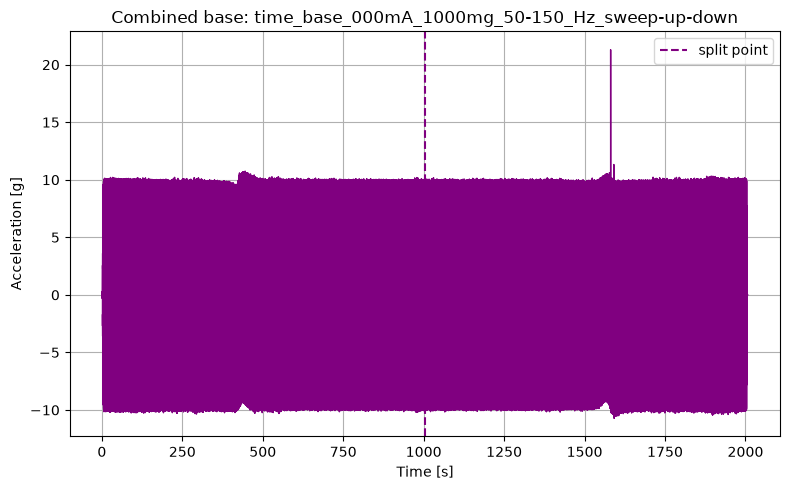

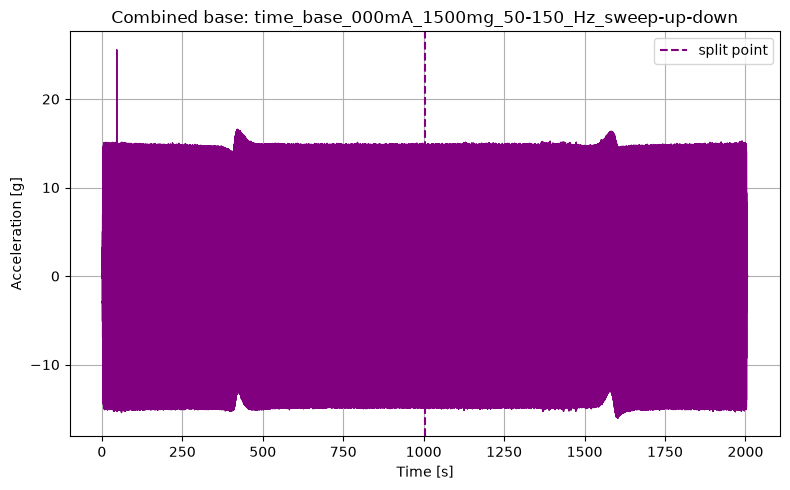

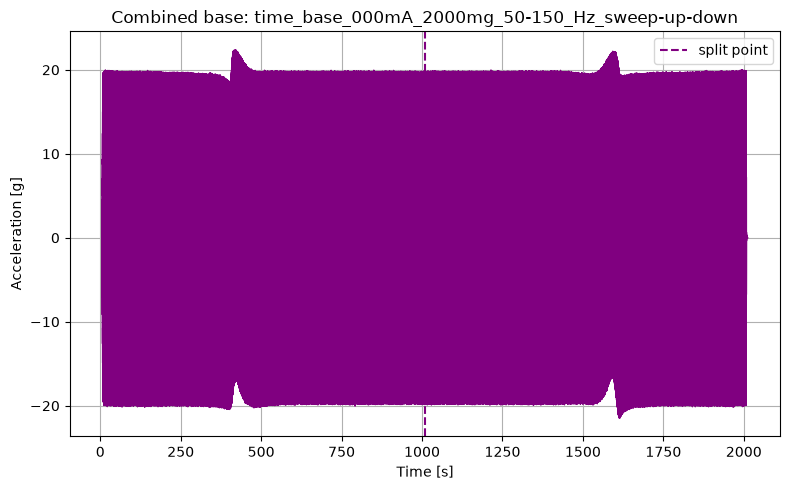

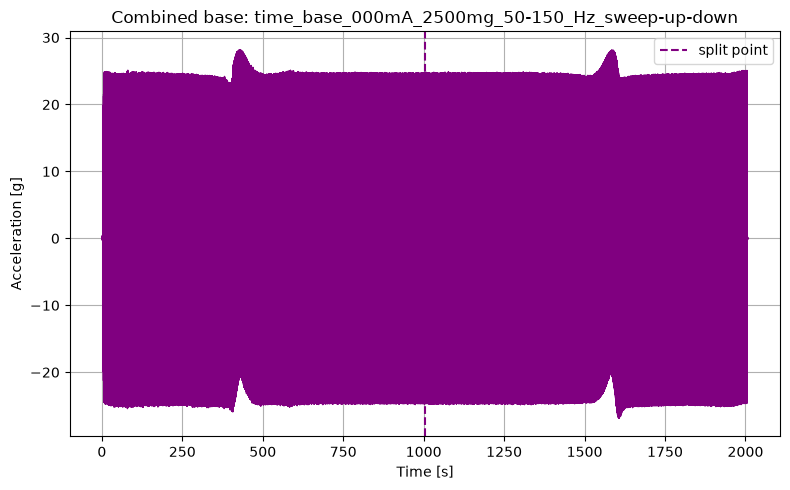

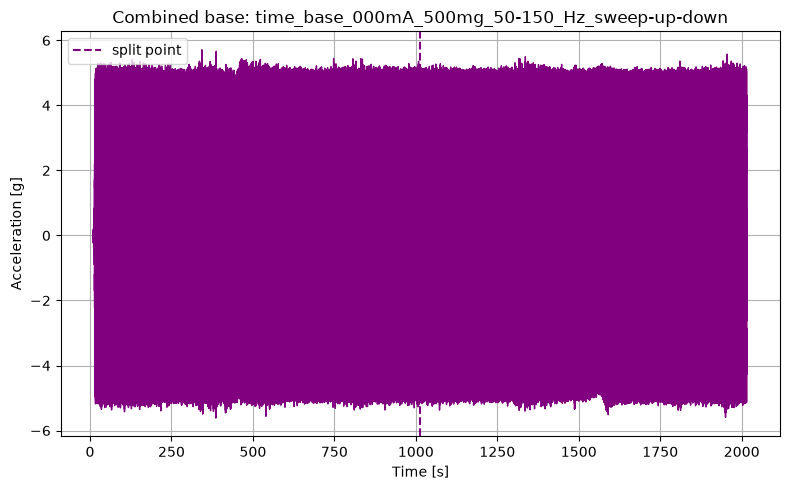

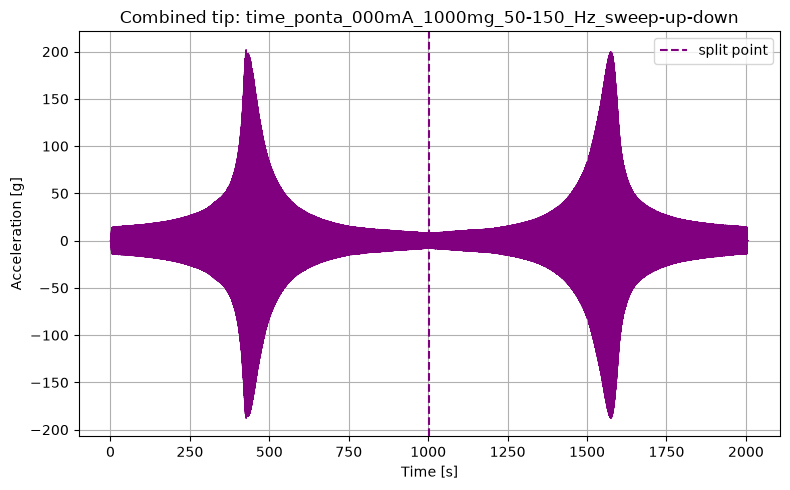

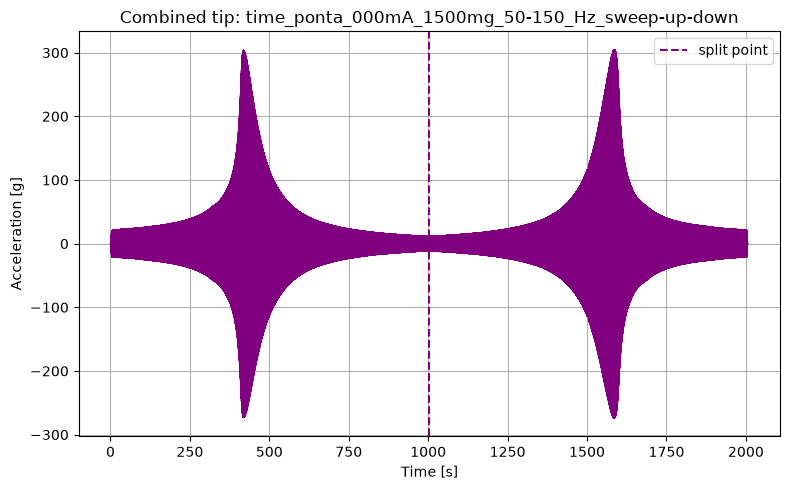

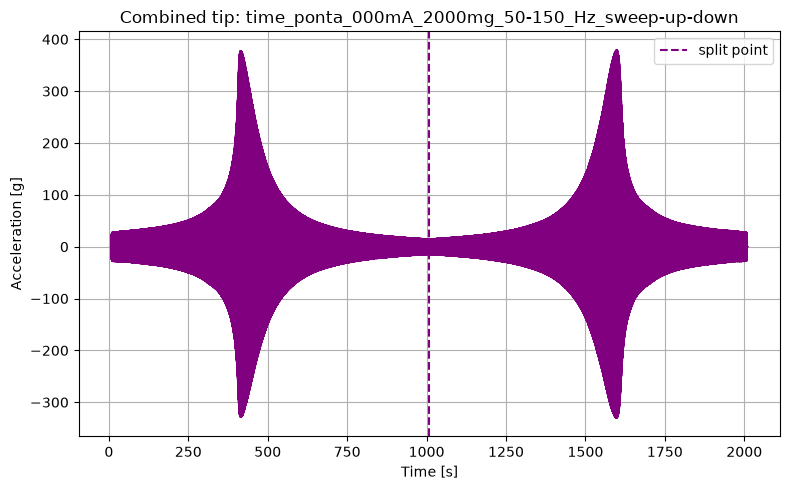

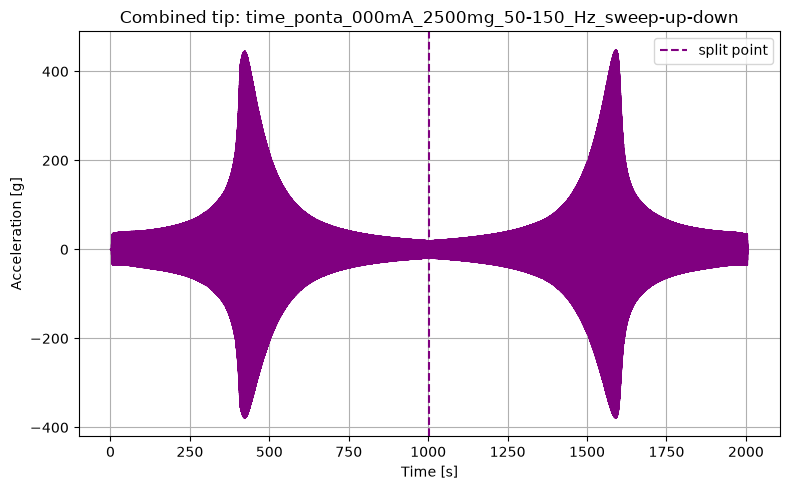

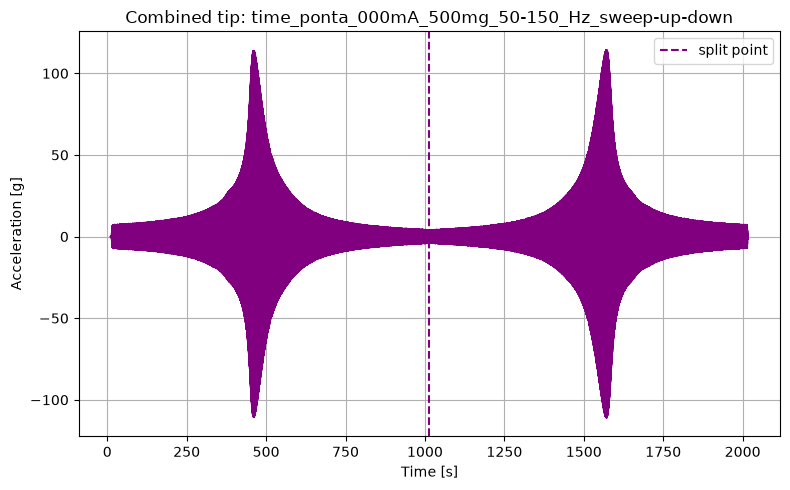

In [7]:
for label, signals in [("base", time_base), ("tip", time_tip)]:
    for key, values in signals.items():
        t = time_axis[key]
        middle = len(t) // 2

        plt.figure(figsize=(8, 5))
        plt.plot(t, values, color="purple", linewidth=1.0)
        plt.axvline(t[middle], color="purple", linestyle="--", label="split point")
        plt.xlabel("Time [s]")
        plt.ylabel("Acceleration [g]")
        plt.title(f"Combined {label}: {key}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


## Split time-domain plots


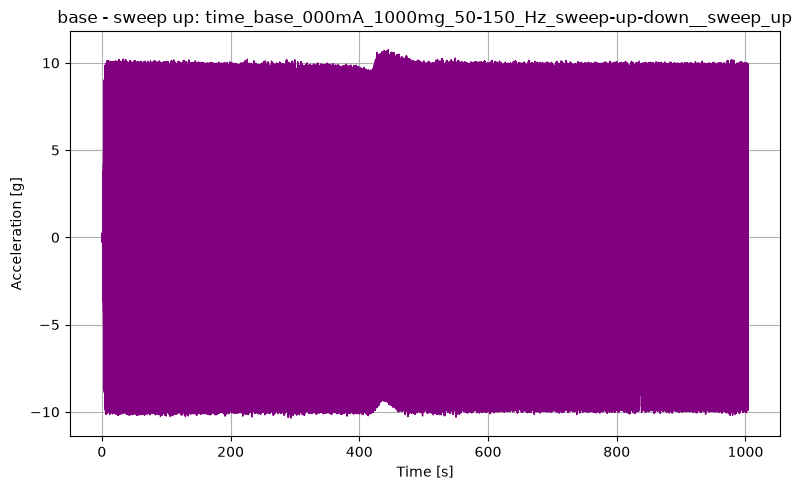

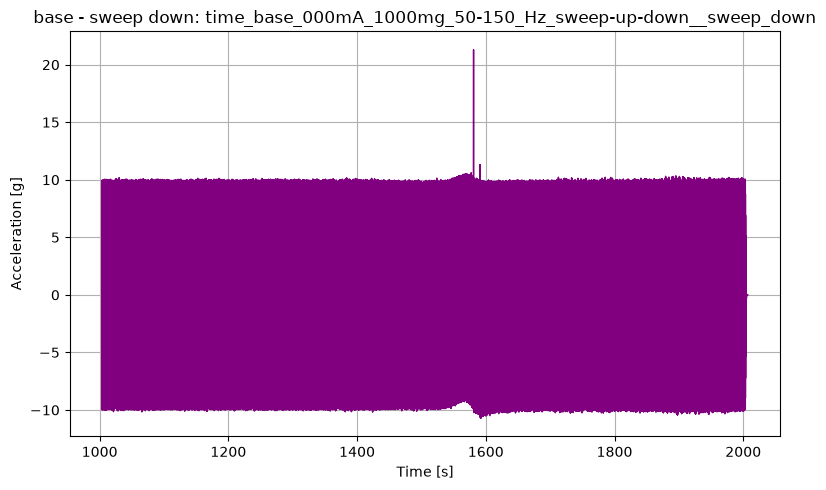

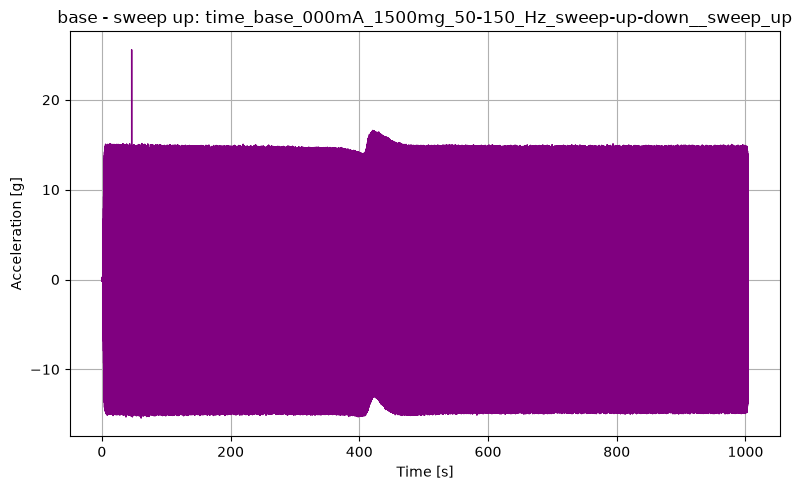

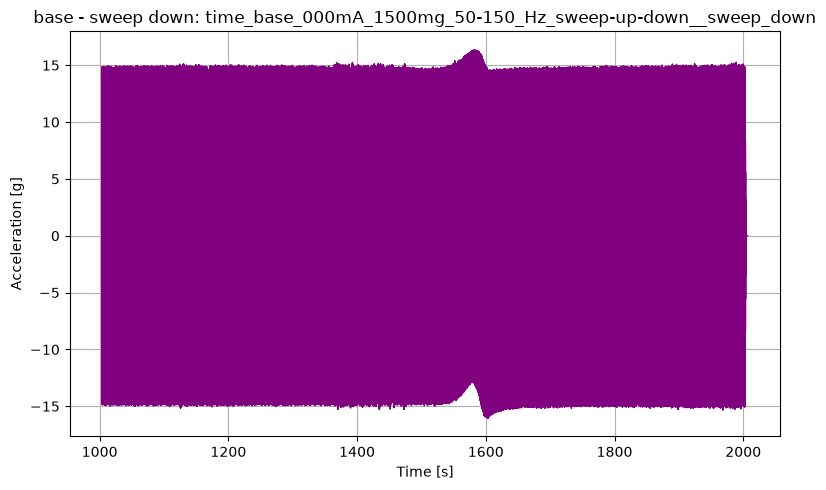

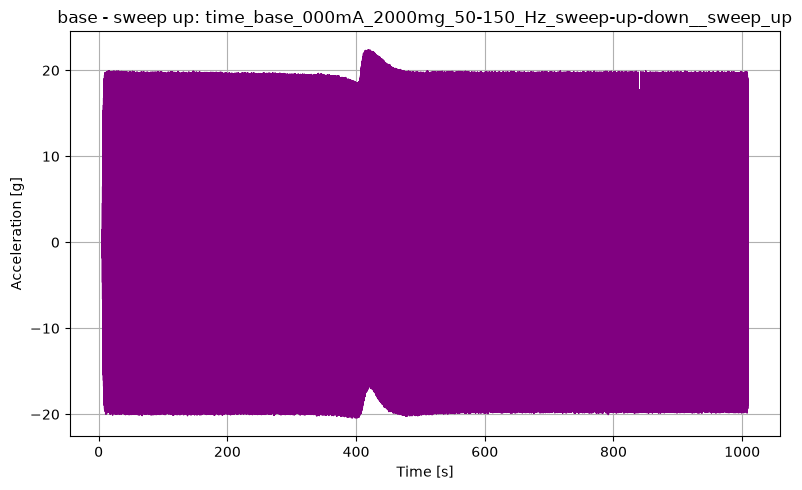

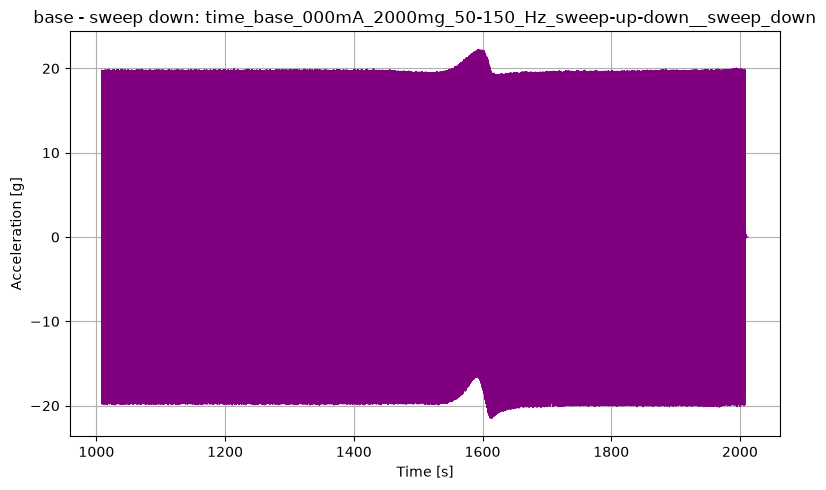

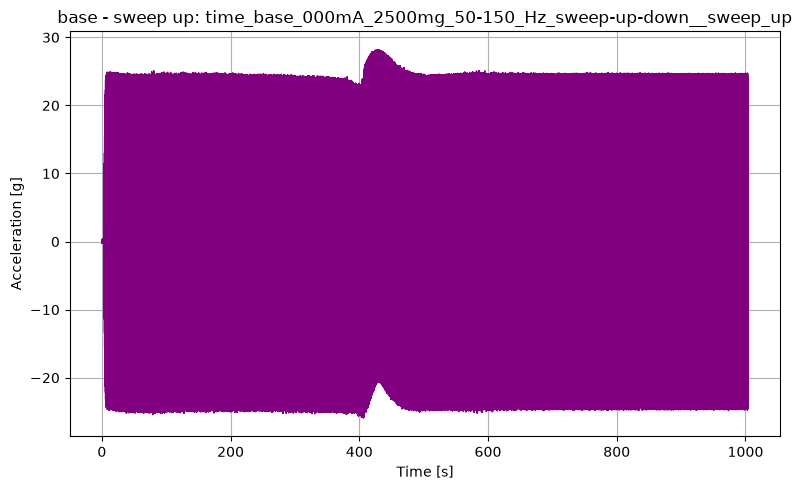

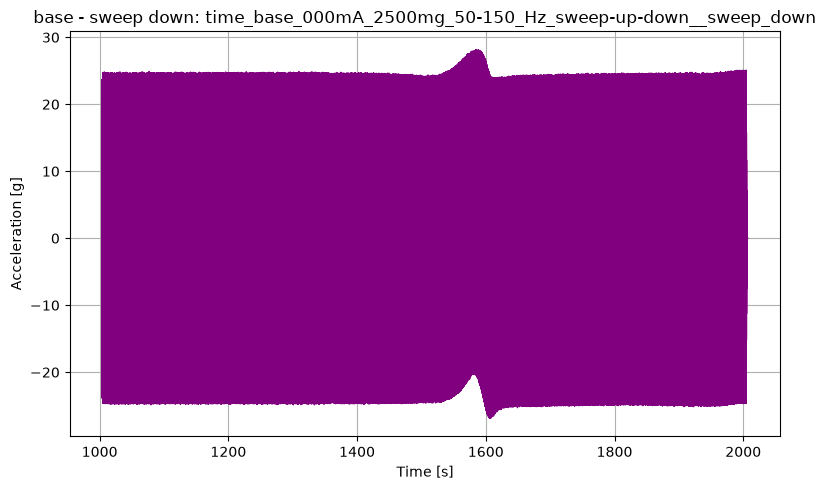

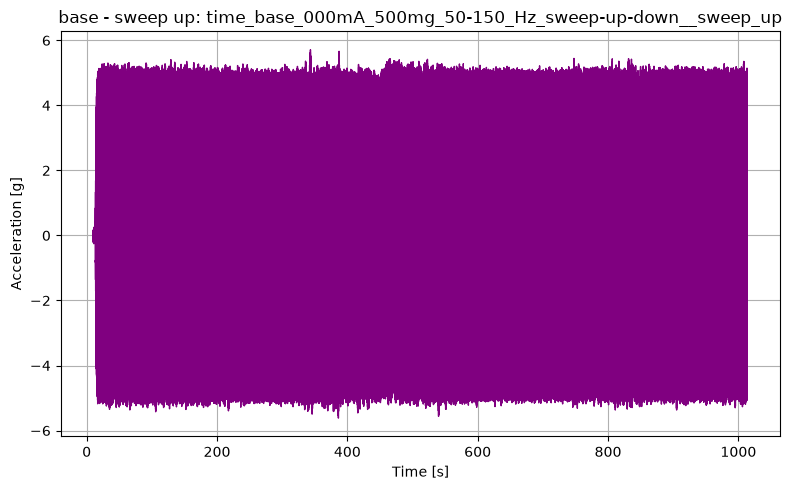

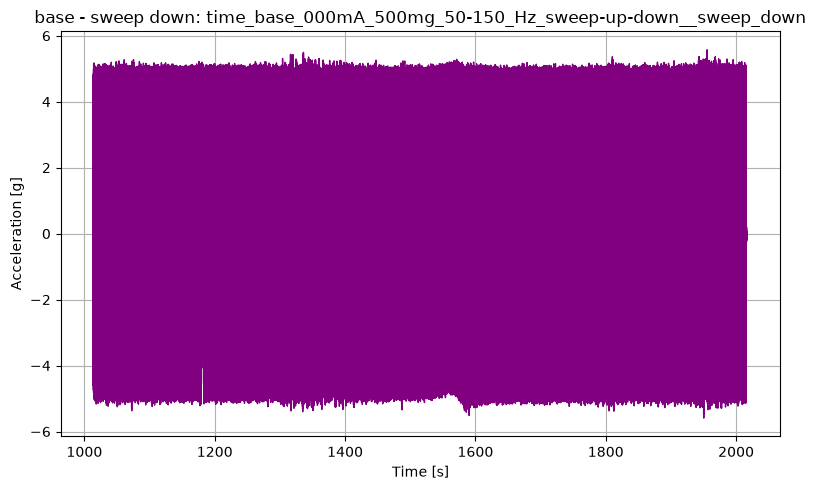

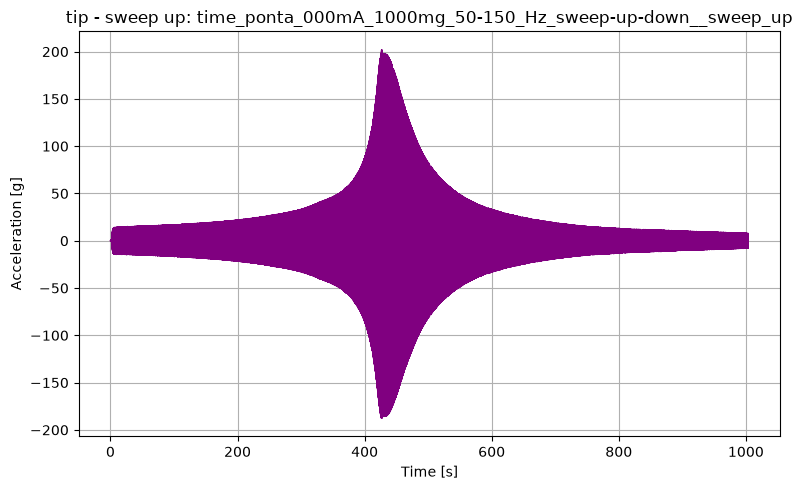

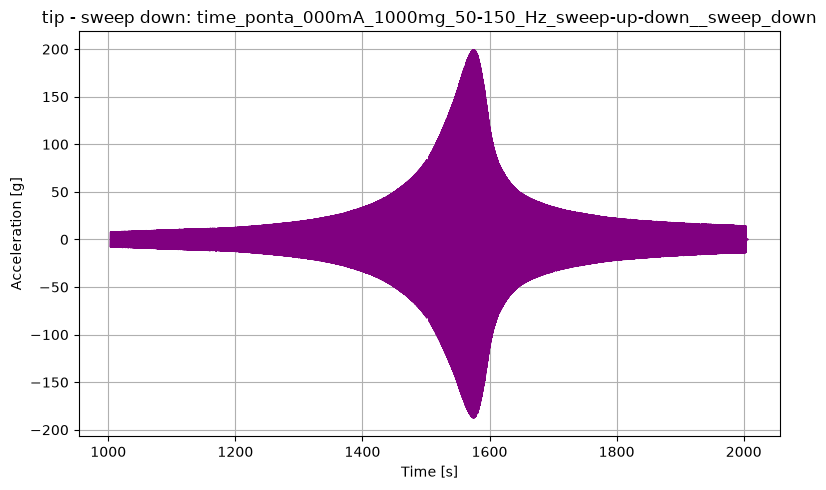

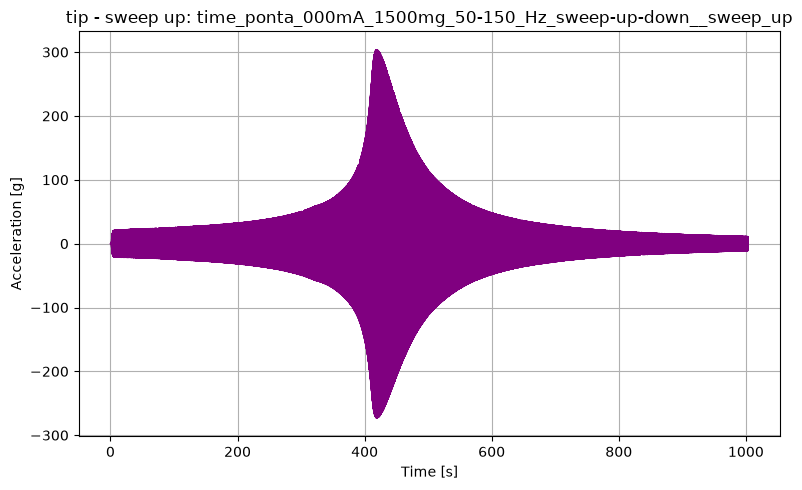

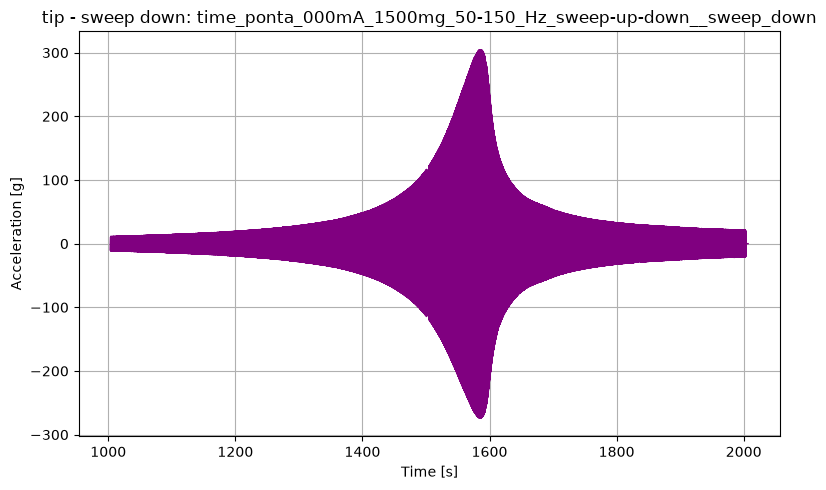

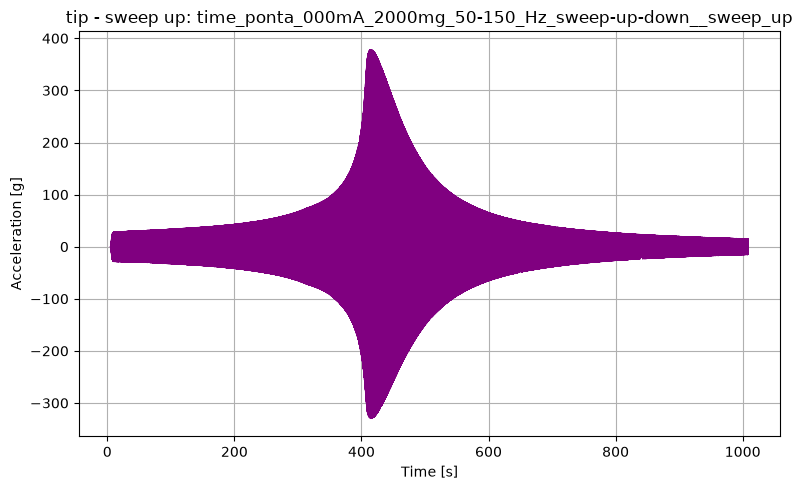

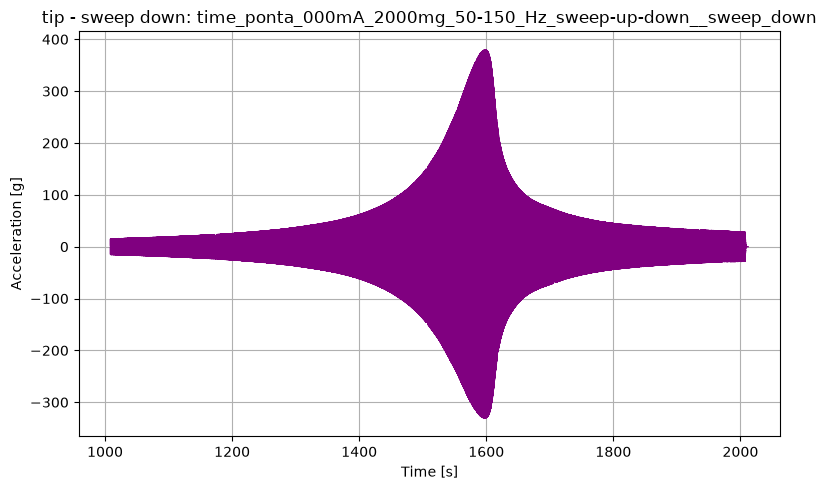

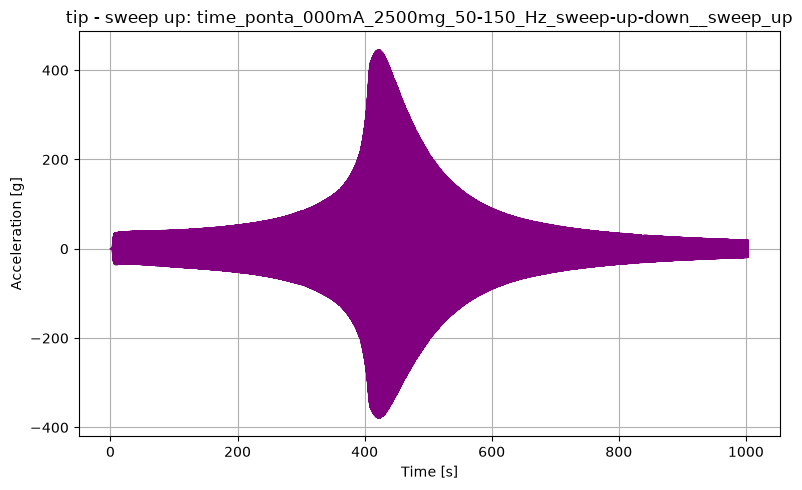

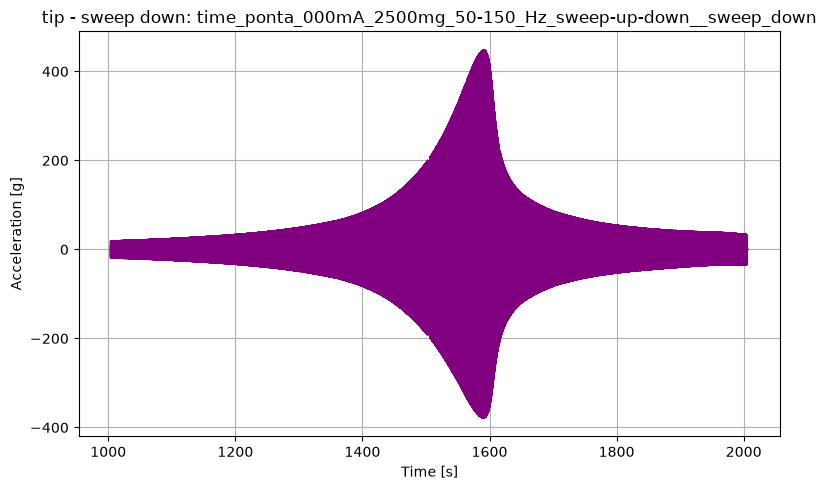

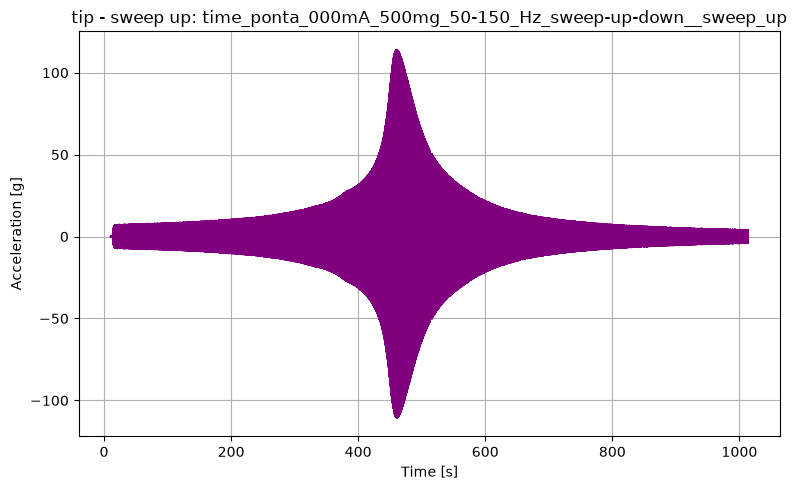

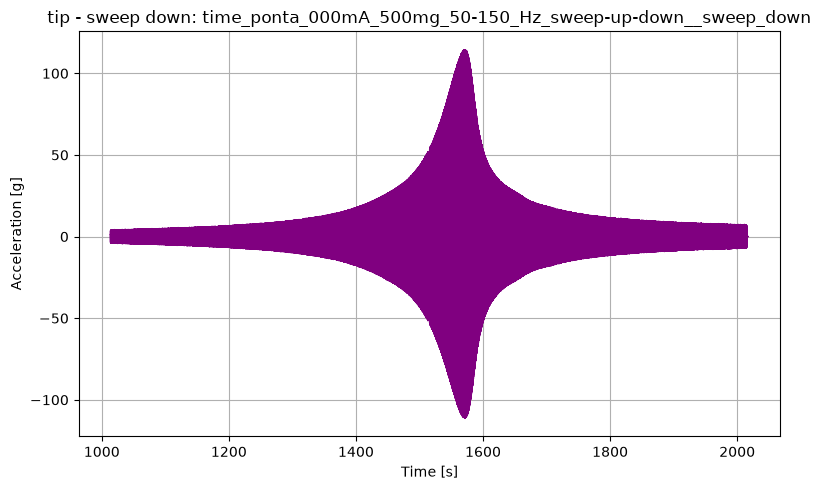

In [8]:
for label, signals in [("base", time_base_split), ("tip", time_tip_split)]:
    for key, values in signals.items():
        t = time_axis_split[key]
        sweep = "sweep up" if key.endswith("__sweep_up") else "sweep down"

        plt.figure(figsize=(8, 5))
        plt.plot(t, values, color="purple", linewidth=1.0)
        plt.xlabel("Time [s]")
        plt.ylabel("Acceleration [g]")
        plt.title(f"{label} - {sweep}: {key}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [9]:
processed_data = {
    "raw_data": raw_data,
    "FRF": FRF,
    "time_base": time_base,
    "time_tip": time_tip,
    "time_axis": time_axis,
    "time_base_split": time_base_split,
    "time_tip_split": time_tip_split,
    "time_axis_split": time_axis_split,
}

output_file = DATA_DIR / "Ana_PySINDy_SNLR_loaded_data.pkl"
with open(output_file, "wb") as file:
    pickle.dump(processed_data, file)

print(f"Saved: {output_file}")


Saved: c:\Users\anacs\Documentos\ic-labdin\BEPE\Data\Ana_PySINDy_SNLR\Ana_PySINDy_SNLR_loaded_data.pkl


In [10]:
def describe_saved_value(value):
    if isinstance(value, dict):
        return f"dict with {len(value)} entries"

    if hasattr(value, "_fieldnames"):
        return f"MATLAB struct with fields={list(value._fieldnames)}"

    array = np.asarray(value)
    return f"array shape={array.shape}, dtype={array.dtype}"


print("Saved structure summary")
print("=" * 80)

for structure_name, structure in processed_data.items():
    print()
    print(f"{structure_name}: {describe_saved_value(structure)}")

    if isinstance(structure, dict):
        for key, value in structure.items():
            print(f"  {key}: {describe_saved_value(value)}")

            if hasattr(value, "_fieldnames"):
                for field in value._fieldnames:
                    field_value = getattr(value, field)
                    print(f"    .{field}: {describe_saved_value(field_value)}")

print()
print("Saved file:", output_file)


Saved structure summary

raw_data: dict with 20 entries
  FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-down: dict with 1 entries
  FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-up: dict with 1 entries
  FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-down: dict with 1 entries
  FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-up: dict with 1 entries
  FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-down: dict with 1 entries
  FRF_ponta-base_000mA_2000mg_50-150_Hz_sweep-up: dict with 1 entries
  FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-down: dict with 1 entries
  FRF_ponta-base_000mA_2500mg_50-150_Hz_sweep-up: dict with 1 entries
  FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-down: dict with 1 entries
  FRF_ponta-base_000mA_500mg_50-150_Hz_sweep-up: dict with 1 entries
  time_base_000mA_1000mg_50-150_Hz_sweep-up-down: dict with 1 entries
  time_base_000mA_1500mg_50-150_Hz_sweep-up-down: dict with 1 entries
  time_base_000mA_2000mg_50-150_Hz_sweep-up-down: dict with 1 entries
  time_base_000mA_2500mg_5

In [11]:
# Test parameter summary extracted from file names.
def parse_test_parameters(file_key):
    pattern = re.compile(
        r"(?P<current_mA>\d+)mA_"
        r"(?P<excitation_amplitude_mg>\d+)mg_"
        r"(?P<freq_min_Hz>\d+(?:\.\d+)?)-(?P<freq_max_Hz>\d+(?:\.\d+)?)_Hz_"
        r"(?P<sweep>sweep-(?:up|down|up-down))"
    )
    match = pattern.search(file_key)
    if match is None:
        return None

    parameters = match.groupdict()
    parameters["current_mA"] = float(parameters["current_mA"])
    parameters["current_A"] = parameters["current_mA"] / 1000.0
    parameters["excitation_amplitude_mg"] = float(parameters["excitation_amplitude_mg"])
    parameters["excitation_amplitude_g"] = parameters["excitation_amplitude_mg"] / 1000.0
    parameters["freq_min_Hz"] = float(parameters["freq_min_Hz"])
    parameters["freq_max_Hz"] = float(parameters["freq_max_Hz"])
    parameters["freq_bandwidth_Hz"] = parameters["freq_max_Hz"] - parameters["freq_min_Hz"]
    return parameters


all_file_keys = sorted(raw_data.keys())
test_parameters = {
    key: parse_test_parameters(key)
    for key in all_file_keys
}
test_parameters = {
    key: value
    for key, value in test_parameters.items()
    if value is not None
}

print("Test parameter summary")
print("=" * 80)
print(f"Files with test parameters: {len(test_parameters)}")

if test_parameters:
    excitation_amplitudes_mg = sorted({params["excitation_amplitude_mg"] for params in test_parameters.values()})
    currents_mA = sorted({params["current_mA"] for params in test_parameters.values()})
    freq_ranges = sorted({(params["freq_min_Hz"], params["freq_max_Hz"]) for params in test_parameters.values()})
    sweeps = sorted({params["sweep"] for params in test_parameters.values()})

    print()
    print("Unique values found:")
    print(f"  excitation amplitudes: {excitation_amplitudes_mg} mg")
    print(f"  excitation amplitudes: {[amplitude / 1000 for amplitude in excitation_amplitudes_mg]} g")
    print(f"  currents: {currents_mA} mA")
    print(f"  currents: {[current / 1000 for current in currents_mA]} A")
    print(f"  frequency ranges: {freq_ranges} Hz")
    print(f"  sweep types: {sweeps}")

    print()
    print("Per-file parameters:")
    for key, params in test_parameters.items():
        print()
        print(key)
        print(f"  current = {params['current_mA']:.6g} mA = {params['current_A']:.6g} A")
        print(f"  excitation amplitude = {params['excitation_amplitude_mg']:.6g} mg = {params['excitation_amplitude_g']:.6g} g")
        print(f"  frequency range = {params['freq_min_Hz']:.6g} to {params['freq_max_Hz']:.6g} Hz")
        print(f"  bandwidth = {params['freq_bandwidth_Hz']:.6g} Hz")
        print(f"  sweep = {params['sweep']}")

processed_data["test_parameters"] = test_parameters
print()
print("Added to processed_data: test_parameters")


Test parameter summary
Files with test parameters: 20

Unique values found:
  excitation amplitudes: [500.0, 1000.0, 1500.0, 2000.0, 2500.0] mg
  excitation amplitudes: [0.5, 1.0, 1.5, 2.0, 2.5] g
  currents: [0.0] mA
  currents: [0.0] A
  frequency ranges: [(50.0, 150.0)] Hz
  sweep types: ['sweep-down', 'sweep-up']

Per-file parameters:

FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-down
  current = 0 mA = 0 A
  excitation amplitude = 1000 mg = 1 g
  frequency range = 50 to 150 Hz
  bandwidth = 100 Hz
  sweep = sweep-down

FRF_ponta-base_000mA_1000mg_50-150_Hz_sweep-up
  current = 0 mA = 0 A
  excitation amplitude = 1000 mg = 1 g
  frequency range = 50 to 150 Hz
  bandwidth = 100 Hz
  sweep = sweep-up

FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-down
  current = 0 mA = 0 A
  excitation amplitude = 1500 mg = 1.5 g
  frequency range = 50 to 150 Hz
  bandwidth = 100 Hz
  sweep = sweep-down

FRF_ponta-base_000mA_1500mg_50-150_Hz_sweep-up
  current = 0 mA = 0 A
  excitation amplitude = 1500

## Exploratory data analysis


Exploratory data analysis

Pair consistency
  base split signals: 10
  tip split signals: 10
  missing tip pairs: 0
  extra tip signals: 0

Time vector summary
  unique dt values: [0.0025] s
  unique sampling frequencies: [400.0] Hz
  duration range: 1003.44 to 1003.52 s

Signal and relative-acceleration metrics
  analyzed paired split tests: 10
ampl_mg sweep       n      duration_s  base_rms_g  tip_rms_g   rel_rms_g   rel_peak_g   lag_s       band_energy
---------------------------------------------------------------------------------------------------------------
   1000 sweep_down  401377   1003.4400       6.928      38.92       39.88       199.5        0.1      0.9994
   1000 sweep_up    401376   1003.4375       6.934      37.39       38.34       199.7        0.1      0.9995
   1500 sweep_down  401377   1003.4400       10.39      58.36       60.03       305.8        0.1      0.9984
   1500 sweep_up    401376   1003.4375        10.4      55.42       57.26       304.9        0.1     

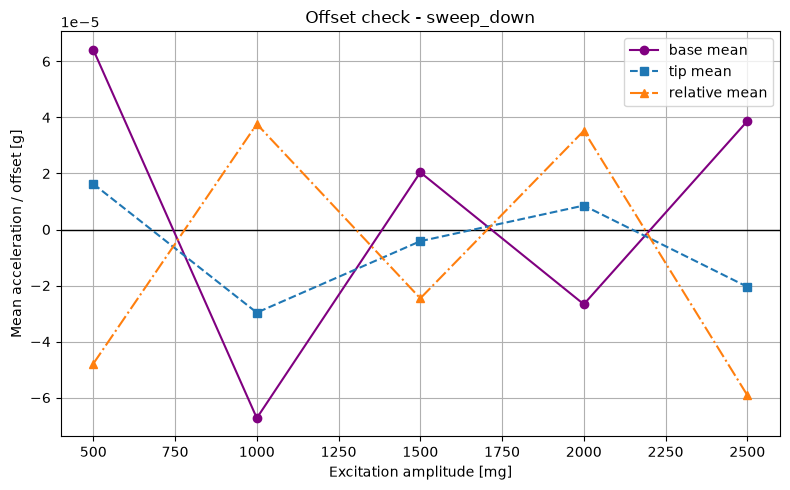

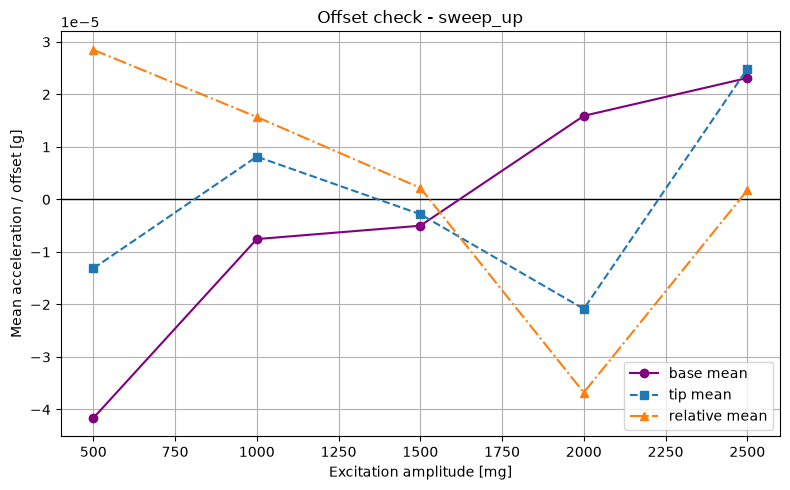

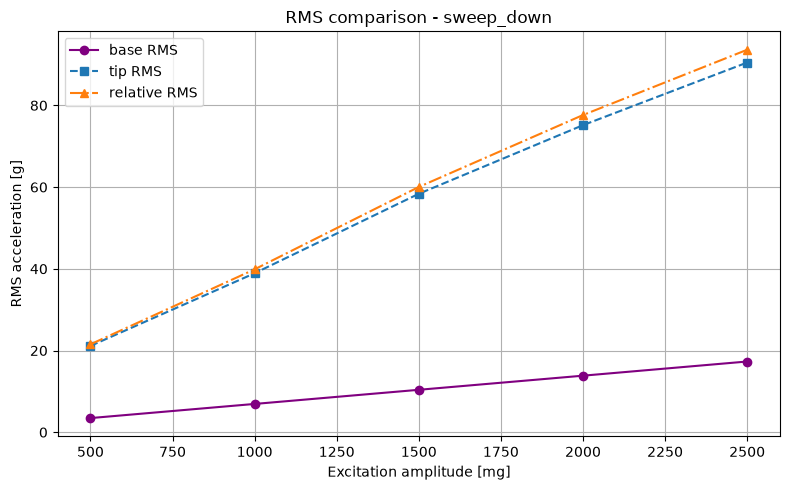

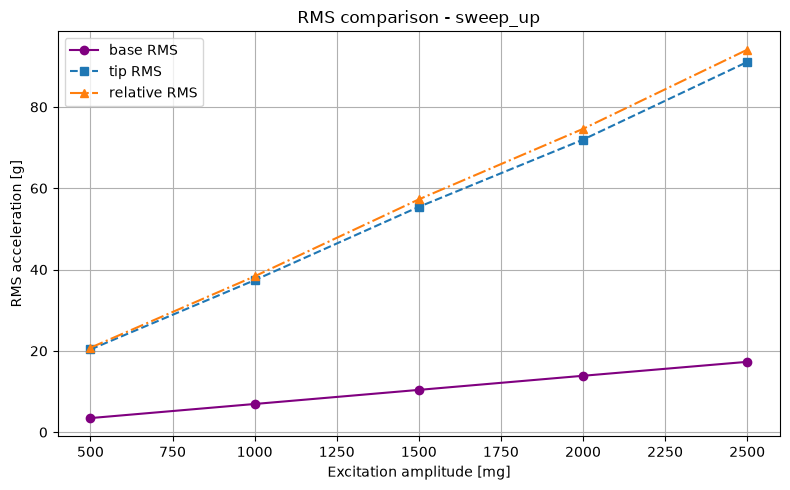


Added to processed_data: exploratory_analysis, relative_acceleration
Updated saved file: c:\Users\anacs\Documentos\ic-labdin\BEPE\Data\Ana_PySINDy_SNLR\Ana_PySINDy_SNLR_loaded_data.pkl


In [12]:
# Exploratory analysis focused on data readiness for integration and PySINDy.
def parse_test_key(key):
    pattern = re.compile(
        r"(?P<current_mA>\d+)mA_"
        r"(?P<excitation_amplitude_mg>\d+)mg_"
        r"(?P<freq_min_Hz>\d+(?:\.\d+)?)-(?P<freq_max_Hz>\d+(?:\.\d+)?)_Hz_"
        r"(?P<sweep>sweep-(?:up|down|up-down))"
    )
    match = pattern.search(key)
    if match is None:
        return {}

    data = match.groupdict()
    data["current_mA"] = float(data["current_mA"])
    data["excitation_amplitude_mg"] = float(data["excitation_amplitude_mg"])
    data["freq_min_Hz"] = float(data["freq_min_Hz"])
    data["freq_max_Hz"] = float(data["freq_max_Hz"])
    data["split_sweep"] = "sweep_up" if key.endswith("__sweep_up") else "sweep_down" if key.endswith("__sweep_down") else "combined"
    return data


def base_to_tip_key(base_key):
    return base_key.replace("time_base", "time_ponta", 1)


def signal_metrics(values, t):
    values = np.asarray(values).squeeze()
    t = np.asarray(t).squeeze()
    finite_values = values[np.isfinite(values)]

    if t.size > 1:
        dt = np.diff(t)
        median_dt = float(np.nanmedian(dt))
        std_dt = float(np.nanstd(dt))
        fs = 1.0 / median_dt if median_dt > 0 else np.nan
        duration = float(t[-1] - t[0])
    else:
        median_dt = np.nan
        std_dt = np.nan
        fs = np.nan
        duration = np.nan

    if finite_values.size == 0:
        return {
            "n": int(values.size),
            "duration_s": duration,
            "dt_s": median_dt,
            "dt_std_s": std_dt,
            "fs_Hz": fs,
            "mean": np.nan,
            "rms": np.nan,
            "peak_abs": np.nan,
            "peak_to_peak": np.nan,
            "nan_count": int(np.isnan(values).sum()),
            "inf_count": int(np.isinf(values).sum()),
        }

    return {
        "n": int(values.size),
        "duration_s": duration,
        "dt_s": median_dt,
        "dt_std_s": std_dt,
        "fs_Hz": fs,
        "mean": float(np.nanmean(values)),
        "rms": float(np.sqrt(np.nanmean(values ** 2))),
        "peak_abs": float(np.nanmax(np.abs(values))),
        "peak_to_peak": float(np.nanmax(values) - np.nanmin(values)),
        "nan_count": int(np.isnan(values).sum()),
        "inf_count": int(np.isinf(values).sum()),
    }


def estimate_lag_seconds(base, tip, t, max_lag_fraction=0.02):
    base = np.asarray(base).squeeze()
    tip = np.asarray(tip).squeeze()
    t = np.asarray(t).squeeze()

    n = min(base.size, tip.size, t.size)
    if n < 10:
        return np.nan, np.nan

    base = base[:n] - np.nanmean(base[:n])
    tip = tip[:n] - np.nanmean(tip[:n])

    # Downsample only for the lag estimate so large files remain quick to analyze.
    step = max(1, n // 20000)
    base_ds = base[::step]
    tip_ds = tip[::step]
    dt = float(np.nanmedian(np.diff(t))) * step

    max_lag = max(1, int(max_lag_fraction * base_ds.size))
    corr = np.correlate(tip_ds, base_ds, mode="full")
    center = base_ds.size - 1
    window = corr[center - max_lag:center + max_lag + 1]
    lag_samples_ds = int(np.argmax(window) - max_lag)
    lag_samples = lag_samples_ds * step
    lag_seconds = lag_samples_ds * dt

    return lag_samples, lag_seconds


def simple_fft_summary(values, t, band=(50.0, 150.0)):
    values = np.asarray(values).squeeze()
    t = np.asarray(t).squeeze()
    n = min(values.size, t.size)
    if n < 4:
        return {
            "dominant_freq_Hz": np.nan,
            "band_peak_freq_Hz": np.nan,
            "band_energy_fraction": np.nan,
        }

    values = values[:n] - np.nanmean(values[:n])
    dt = float(np.nanmedian(np.diff(t[:n])))
    if not np.isfinite(dt) or dt <= 0:
        return {
            "dominant_freq_Hz": np.nan,
            "band_peak_freq_Hz": np.nan,
            "band_energy_fraction": np.nan,
        }

    window = np.hanning(n)
    spectrum = np.fft.rfft(values * window)
    freq = np.fft.rfftfreq(n, d=dt)
    power = np.abs(spectrum) ** 2

    if power.size <= 1 or np.nansum(power[1:]) == 0:
        return {
            "dominant_freq_Hz": np.nan,
            "band_peak_freq_Hz": np.nan,
            "band_energy_fraction": np.nan,
        }

    positive = freq > 0
    dominant_freq = float(freq[positive][np.argmax(power[positive])])

    band_mask = (freq >= band[0]) & (freq <= band[1])
    if np.any(band_mask):
        band_freq = float(freq[band_mask][np.argmax(power[band_mask])])
        band_energy_fraction = float(np.nansum(power[band_mask]) / np.nansum(power[positive]))
    else:
        band_freq = np.nan
        band_energy_fraction = np.nan

    return {
        "dominant_freq_Hz": dominant_freq,
        "band_peak_freq_Hz": band_freq,
        "band_energy_fraction": band_energy_fraction,
    }


print("Exploratory data analysis")
print("=" * 80)

# 1. Pair consistency for split signals.
expected_tip_keys = {base_to_tip_key(key) for key in time_base_split.keys()}
actual_tip_keys = set(time_tip_split.keys())
missing_tip = sorted(expected_tip_keys - actual_tip_keys)
extra_tip = sorted(actual_tip_keys - expected_tip_keys)

print("\nPair consistency")
print(f"  base split signals: {len(time_base_split)}")
print(f"  tip split signals: {len(time_tip_split)}")
print(f"  missing tip pairs: {len(missing_tip)}")
print(f"  extra tip signals: {len(extra_tip)}")
if missing_tip:
    print("  missing tip keys:")
    for key in missing_tip:
        print(f"    {key}")
if extra_tip:
    print("  extra tip keys:")
    for key in extra_tip:
        print(f"    {key}")

# 2. Time vector summary.
time_summaries = {}
for key, t in time_axis_split.items():
    t = np.asarray(t).squeeze()
    if t.size > 1:
        dt = np.diff(t)
        time_summaries[key] = {
            "n": int(t.size),
            "duration_s": float(t[-1] - t[0]),
            "dt_s": float(np.nanmedian(dt)),
            "dt_std_s": float(np.nanstd(dt)),
            "fs_Hz": float(1.0 / np.nanmedian(dt)),
        }

print("\nTime vector summary")
if time_summaries:
    dt_values = sorted({round(item["dt_s"], 12) for item in time_summaries.values()})
    fs_values = sorted({round(item["fs_Hz"], 6) for item in time_summaries.values()})
    durations = [item["duration_s"] for item in time_summaries.values()]
    print(f"  unique dt values: {dt_values} s")
    print(f"  unique sampling frequencies: {fs_values} Hz")
    print(f"  duration range: {min(durations):.6g} to {max(durations):.6g} s")

# 3. Signal metrics and relative acceleration.
exploratory_rows = []
relative_acceleration = {}

for base_key, base_values in sorted(time_base_split.items()):
    tip_key = base_to_tip_key(base_key)
    if tip_key not in time_tip_split:
        continue

    t = np.asarray(time_axis_split[base_key]).squeeze()
    base = np.asarray(base_values).squeeze()
    tip = np.asarray(time_tip_split[tip_key]).squeeze()
    n = min(t.size, base.size, tip.size)

    t = t[:n]
    base = base[:n]
    tip = tip[:n]
    rel = tip - base
    relative_acceleration[base_key.replace("time_base", "relative_acceleration", 1)] = rel

    info = parse_test_key(base_key)
    base_metrics = signal_metrics(base, t)
    tip_metrics = signal_metrics(tip, t)
    rel_metrics = signal_metrics(rel, t)
    rel_fft = simple_fft_summary(rel, t, band=(info.get("freq_min_Hz", 50.0), info.get("freq_max_Hz", 150.0)))
    lag_samples, lag_seconds = estimate_lag_seconds(base, tip, t)

    exploratory_rows.append({
        "key": base_key,
        "excitation_amplitude_mg": info.get("excitation_amplitude_mg", np.nan),
        "current_mA": info.get("current_mA", np.nan),
        "split_sweep": info.get("split_sweep", "unknown"),
        "n": n,
        "duration_s": base_metrics["duration_s"],
        "dt_s": base_metrics["dt_s"],
        "fs_Hz": base_metrics["fs_Hz"],
        "base_mean_g": base_metrics["mean"],
        "tip_mean_g": tip_metrics["mean"],
        "rel_mean_g": rel_metrics["mean"],
        "base_rms_g": base_metrics["rms"],
        "tip_rms_g": tip_metrics["rms"],
        "rel_rms_g": rel_metrics["rms"],
        "base_peak_g": base_metrics["peak_abs"],
        "tip_peak_g": tip_metrics["peak_abs"],
        "rel_peak_g": rel_metrics["peak_abs"],
        "base_pp_g": base_metrics["peak_to_peak"],
        "tip_pp_g": tip_metrics["peak_to_peak"],
        "rel_pp_g": rel_metrics["peak_to_peak"],
        "lag_samples_tip_vs_base": lag_samples,
        "lag_seconds_tip_vs_base": lag_seconds,
        "rel_dominant_freq_Hz": rel_fft["dominant_freq_Hz"],
        "rel_band_peak_freq_Hz": rel_fft["band_peak_freq_Hz"],
        "rel_band_energy_fraction": rel_fft["band_energy_fraction"],
        "nan_count_total": base_metrics["nan_count"] + tip_metrics["nan_count"],
        "inf_count_total": base_metrics["inf_count"] + tip_metrics["inf_count"],
    })

print("\nSignal and relative-acceleration metrics")
print(f"  analyzed paired split tests: {len(exploratory_rows)}")
header = (
    "ampl_mg sweep       n      duration_s  base_rms_g  tip_rms_g   rel_rms_g   "
    "rel_peak_g   lag_s       band_energy"
)
print(header)
print("-" * len(header))
for row in exploratory_rows:
    print(
        f"{row['excitation_amplitude_mg']:7.0f} {row['split_sweep']:<10} "
        f"{row['n']:7d} {row['duration_s']:11.4f} "
        f"{row['base_rms_g']:11.4g} {row['tip_rms_g']:10.4g} {row['rel_rms_g']:11.4g} "
        f"{row['rel_peak_g']:11.4g} {row['lag_seconds_tip_vs_base']:10.4g} "
        f"{row['rel_band_energy_fraction']:11.4g}"
    )

# 4. Explicit offset check.
print("\nOffset check")
print("  Offset is the signal mean. Large acceleration offset can create drift during integration.")
offset_header = "ampl_mg sweep       base_mean_g   tip_mean_g    rel_mean_g    base_offset/RMS  tip_offset/RMS   rel_offset/RMS"
print(offset_header)
print("-" * len(offset_header))

for row in exploratory_rows:
    base_ratio = abs(row["base_mean_g"]) / row["base_rms_g"] if row["base_rms_g"] else np.nan
    tip_ratio = abs(row["tip_mean_g"]) / row["tip_rms_g"] if row["tip_rms_g"] else np.nan
    rel_ratio = abs(row["rel_mean_g"]) / row["rel_rms_g"] if row["rel_rms_g"] else np.nan
    print(
        f"{row['excitation_amplitude_mg']:7.0f} {row['split_sweep']:<10} "
        f"{row['base_mean_g']:12.4g} {row['tip_mean_g']:12.4g} {row['rel_mean_g']:12.4g} "
        f"{base_ratio:15.4g} {tip_ratio:15.4g} {rel_ratio:15.4g}"
    )

if exploratory_rows:
    for sweep_name in sorted({row["split_sweep"] for row in exploratory_rows}):
        rows = sorted([row for row in exploratory_rows if row["split_sweep"] == sweep_name], key=lambda item: item["excitation_amplitude_mg"])
        excitation_amplitudes = np.array([row["excitation_amplitude_mg"] for row in rows])

        plt.figure(figsize=(8, 5))
        plt.axhline(0.0, color="black", linewidth=1.0)
        plt.plot(excitation_amplitudes, [row["base_mean_g"] for row in rows], "o-", color="purple", label="base mean")
        plt.plot(excitation_amplitudes, [row["tip_mean_g"] for row in rows], "s--", color="tab:blue", label="tip mean")
        plt.plot(excitation_amplitudes, [row["rel_mean_g"] for row in rows], "^-.", color="tab:orange", label="relative mean")
        plt.xlabel("Excitation amplitude [mg]")
        plt.ylabel("Mean acceleration / offset [g]")
        plt.title(f"Offset check - {sweep_name}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# 5. Compact plots that add new information: RMS vs mass for base, tip, and relative acceleration.
if exploratory_rows:
    for sweep_name in sorted({row["split_sweep"] for row in exploratory_rows}):
        rows = sorted([row for row in exploratory_rows if row["split_sweep"] == sweep_name], key=lambda item: item["excitation_amplitude_mg"])
        excitation_amplitudes = np.array([row["excitation_amplitude_mg"] for row in rows])

        plt.figure(figsize=(8, 5))
        plt.plot(excitation_amplitudes, [row["base_rms_g"] for row in rows], "o-", color="purple", label="base RMS")
        plt.plot(excitation_amplitudes, [row["tip_rms_g"] for row in rows], "s--", color="tab:blue", label="tip RMS")
        plt.plot(excitation_amplitudes, [row["rel_rms_g"] for row in rows], "^-.", color="tab:orange", label="relative RMS")
        plt.xlabel("Excitation amplitude [mg]")
        plt.ylabel("RMS acceleration [g]")
        plt.title(f"RMS comparison - {sweep_name}")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# 6. Store analysis results for later use.
exploratory_analysis = {
    "pair_consistency": {
        "missing_tip": missing_tip,
        "extra_tip": extra_tip,
    },
    "time_summaries": time_summaries,
    "rows": exploratory_rows,
    "relative_acceleration": relative_acceleration,
}

processed_data["exploratory_analysis"] = exploratory_analysis
processed_data["relative_acceleration"] = relative_acceleration

with open(output_file, "wb") as file:
    pickle.dump(processed_data, file)

print("\nAdded to processed_data: exploratory_analysis, relative_acceleration")
print(f"Updated saved file: {output_file}")
